# Telecommunications Customer Retention Analytics Using Python

**Author:** Khushi Sharma

**Project Type:** Exploratory Data Analysis (EDA)

**Tools:** Python | Pandas | Matplotlib | Google Colab

**Dataset:** IBM Telco Customer Churn Dataset (Kaggle)

**Date:** July 2026

---





# Customer Retention Analytics: Telecommunications Case Study

## Business Problem

Customer churn is one of the most significant challenges faced by telecommunications companies. Losing existing customers reduces recurring revenue and increases customer acquisition costs.

This project analyses customer behaviour using Python to identify the major factors associated with customer churn and provides data-driven business recommendations to improve customer retention.

---

## Project Objectives

This project aims to:

- Clean and validate the customer dataset.
- Perform Exploratory Data Analysis (EDA).
- Identify the key factors associated with customer churn.
- Identify customer groups with higher churn risk.
- Provide business recommendations based on analytical findings.

---

## Tools Used

- Python
- Google Colab
- Pandas
- Matplotlib
- Kaggle (IBM Telco Customer Churn Dataset)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Dataset Overview

The IBM Telco Customer Churn dataset contains information for **7,043 customers**.

The dataset includes:

- Customer demographics
- Account information
- Internet services
- Contract details
- Monthly and total charges
- Customer churn status

The objective is to identify the business factors associated with customer churn.

In [2]:
df.head()

df.shape

df.columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning

Before analysing the dataset, several data quality checks were performed to ensure reliable results.

The following steps were completed:

- Investigated incorrect data types.
- Identified blank values in the `TotalCharges` column.
- Converted `TotalCharges` to numeric format.
- Checked for duplicate customer records.

In [3]:
# Inspect TotalCharges

df["TotalCharges"].unique()[:20]

df["TotalCharges"].value_counts().tail()

# Find blank values

df[df["TotalCharges"].str.strip() == ""]

# Replace blank values with 0
# Customers with zero tenure have not accumulated any charges.

df["TotalCharges"] = df["TotalCharges"].replace(" ", 0)

# Convert to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Verify data types

df.info()

# Check duplicate customer IDs

df["customerID"].duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

# Exploratory Data Analysis (EDA)

The following analyses investigate the major business factors associated with customer churn.

## Analysis 1: Overall Customer Churn

### Business Question

What proportion of customers have left the company?

In [4]:
df["Churn"].value_counts()

churn_rate = df["Churn"].value_counts(normalize=True) * 100

churn_rate

,proportion
Churn,
No,73.463013
Yes,26.536987


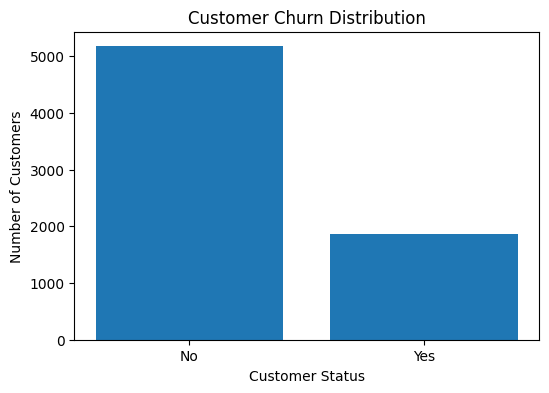

In [5]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")

plt.xlabel("Customer Status")

plt.ylabel("Number of Customers")

plt.show()

### Key Finding

Approximately **26.5%** of customers have churned, meaning that roughly one in every four customers has left the company.

### Business Interpretation

Customer retention represents a significant business challenge requiring further investigation into the factors influencing churn.

## Analysis 2: Contract Type vs Customer Churn

### Business Question

Does contract type influence customer churn?

In [6]:
pd.crosstab(df["Contract"], df["Churn"])

contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Key Finding

Month-to-month customers have the highest churn rate at approximately **42.7%**, while two-year contract customers have a churn rate of only **2.8%**.

### Business Interpretation

Long-term contracts are strongly associated with customer retention.

### Business Recommendation

Encourage month-to-month customers to transition to longer contracts through loyalty benefits, discounts and targeted offers.

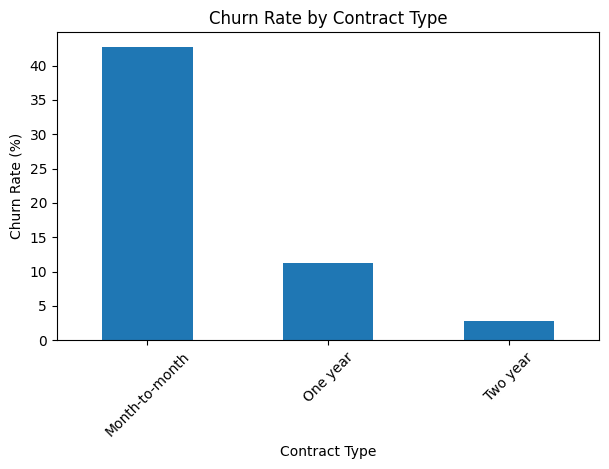

In [7]:
contract_churn_rate["Yes"].plot(kind="bar", figsize=(7,4))

plt.title("Churn Rate by Contract Type")

plt.xlabel("Contract Type")

plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=45)

plt.show()

## Analysis 3: Customer Tenure vs Customer Churn

### Business Question

Do customers who leave the company have shorter relationships compared with retained customers?

Customer tenure helps identify whether churn occurs early or later in the customer lifecycle.

In [8]:
# Calculate average tenure by churn status

tenure_churn = df.groupby("Churn")["tenure"].mean()

tenure_churn

,tenure
Churn,
No,37.569965
Yes,17.979133


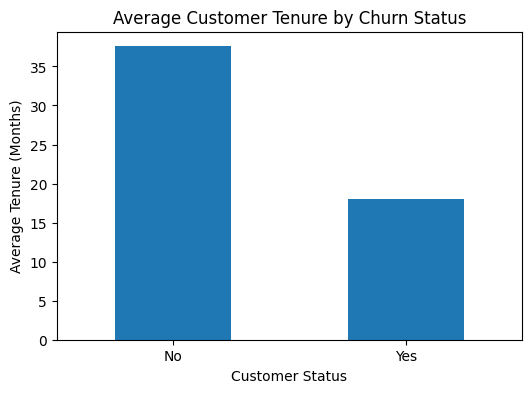

In [9]:
# Visualisation

tenure_churn.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Customer Tenure by Churn Status")

plt.xlabel("Customer Status")

plt.ylabel("Average Tenure (Months)")

plt.xticks(rotation=0)

plt.show()

### Key Finding

Customers who churn have an average tenure of approximately **18 months**, compared with nearly **38 months** for retained customers.

### Business Interpretation

Customers are more likely to leave during the earlier stages of their relationship with the company.

### Business Recommendation

Improve customer onboarding and introduce early engagement strategies to reduce churn during the first year of service.

## Analysis 4: Monthly Charges vs Customer Churn

### Business Question

Are customers with higher monthly charges more likely to leave the telecommunications service?

This analysis investigates whether pricing differences are associated with customer churn behaviour.

In [10]:
# Calculate average monthly charges by churn status

monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()

monthly_charges_churn

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


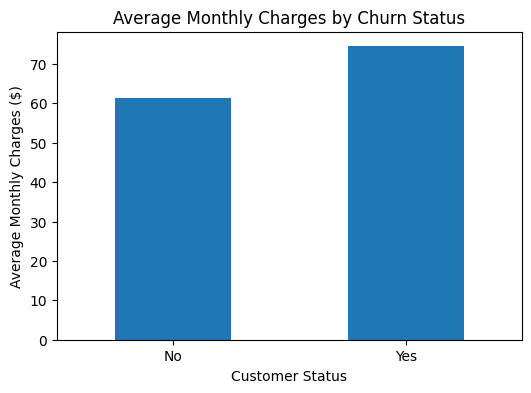

In [11]:
# Visualisation

monthly_charges_churn.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Monthly Charges by Churn Status")

plt.xlabel("Customer Status")

plt.ylabel("Average Monthly Charges ($)")

plt.xticks(rotation=0)

plt.show()

### Key Finding

Customers who churn have higher average monthly charges compared with customers who remain with the service.

### Business Interpretation

Higher monthly charges may contribute to customer dissatisfaction when combined with other factors such as contract type, service quality, or customer expectations.

### Business Recommendation

Review pricing strategies and provide personalised retention offers for higher-value customers who may be at greater risk of leaving.

## Analysis 5: Internet Service vs Customer Churn

### Business Question

Does the type of internet service influence customer churn?

This analysis examines whether customers using different internet services show different churn patterns.

In [12]:
# Calculate churn rate by internet service type

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### Key Finding

Fiber optic customers demonstrate the highest churn rate at approximately **41.9%**, compared with lower churn rates among DSL and customers without internet service.

### Business Interpretation

The higher churn rate among fiber optic customers may indicate potential issues related to pricing, service quality, or customer expectations.

### Business Recommendation

Investigate customer satisfaction among fiber optic users and review service quality, pricing models, and support strategies.

## Analysis 6: Technical Support vs Customer Churn

### Business Question

Does access to technical support influence customer retention?

This analysis evaluates whether customers with technical support services have different churn behaviour compared with customers without support.

In [13]:
# Calculate churn rate by technical support availability

support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


### Key Finding

Customers without technical support have a churn rate of approximately **41.6%**, compared with **15.2%** among customers who have technical support.

### Business Interpretation

Access to technical support appears to be strongly associated with improved customer retention.

### Business Recommendation

Promote technical support services through bundled packages and proactive customer assistance to reduce customer churn.

# Business Recommendations

Based on the analysis, the following recommendations are proposed to improve customer retention:

### 1. Encourage Long-Term Contracts

Customers with month-to-month contracts show significantly higher churn rates compared with customers on longer contracts. Introducing loyalty benefits, discounts, and contract upgrade incentives may improve retention.

### 2. Improve Early Customer Engagement

Customers who churn have shorter average tenure compared with retained customers. Strengthening onboarding processes and providing proactive engagement during the early customer lifecycle may reduce early churn.

### 3. Review Pricing Strategies

Customers with higher monthly charges demonstrate higher churn tendencies. Reviewing pricing structures and offering personalised retention plans may help reduce customer loss.

### 4. Investigate Fiber Optic Customer Experience

Fiber optic customers show the highest churn rate among internet service categories. Further investigation into pricing, service quality, and customer expectations is recommended.

### 5. Promote Technical Support Services

Customers without technical support have significantly higher churn rates. Encouraging customers to adopt support services may improve satisfaction and reduce churn.

# Project Conclusion

This project analysed customer churn behaviour within a telecommunications dataset using Python and exploratory data analysis techniques.

The analysis identified several factors associated with customer churn, including contract type, customer tenure, monthly charges, internet service category, and technical support availability.

The findings demonstrate that customer retention is influenced by both service-related and customer relationship factors. Based on these insights, practical business recommendations were developed to support improved retention strategies.

This project demonstrates the complete data analytics workflow, including data cleaning, exploratory analysis, data visualisation, and business communication.